In [77]:
# Data Manipulation
import numpy as np 
import pandas as pd 

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns 

#NLP
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer

# Word Cloud
from wordcloud import WordCloud

# Topic Modeling
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Machine Learning 
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor)

from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score)

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_excel(r"D:\AnalytixLabs\Data Science & AI\6. Case Studies\Machine Learning Case Studies\5. Capstone Case Study - NLP- Woman Clothing E-Commerce Platform\Womens Clothing Reviews Data.xlsx")

In [3]:
df.head()

,Product ID,Category,Subcategory1,SubCategory2,Location,Channel,Customer Age,Review Title,Review Text,Rating,Recommend Flag
0,767,Initmates,Intimate,Intimates,Mumbai,Mobile,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1
1,1080,General,Dresses,Dresses,Bangalore,Mobile,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1
2,1077,General,Dresses,Dresses,Gurgaon,Mobile,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0
3,1049,General Petite,Bottoms,Pants,Chennai,Web,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1
4,847,General,Tops,Blouses,Bangalore,Web,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Product ID      23486 non-null  int64 
 1   Category        23472 non-null  object
 2   Subcategory1    23472 non-null  object
 3   SubCategory2    23472 non-null  object
 4   Location        23486 non-null  object
 5   Channel         23486 non-null  object
 6   Customer Age    23486 non-null  int64 
 7   Review Title    19676 non-null  object
 8   Review Text     22641 non-null  object
 9   Rating          23486 non-null  int64 
 10  Recommend Flag  23486 non-null  int64 
dtypes: int64(4), object(7)
memory usage: 2.0+ MB


In [5]:
df.isnull().sum()

Product ID           0
Category            14
Subcategory1        14
SubCategory2        14
Location             0
Channel              0
Customer Age         0
Review Title      3810
Review Text        845
Rating               0
Recommend Flag       0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(3)

In [7]:
df.dropna(subset=['Category', 'Subcategory1', 'SubCategory2'],
          inplace= True)

In [8]:
df.columns = df.columns.str.replace(' ', '_')

In [9]:
df.columns

Index(['Product_ID', 'Category', 'Subcategory1', 'SubCategory2', 'Location',
       'Channel', 'Customer_Age', 'Review_Title', 'Review_Text', 'Rating',
       'Recommend_Flag'],
      dtype='object')

In [10]:
df['Review_Title'] = df['Review_Title'].fillna('')

In [11]:
df.head()

,Product_ID,Category,Subcategory1,SubCategory2,Location,Channel,Customer_Age,Review_Title,Review_Text,Rating,Recommend_Flag
0,767,Initmates,Intimate,Intimates,Mumbai,Mobile,33,,Absolutely wonderful - silky and sexy and comf...,4,1
1,1080,General,Dresses,Dresses,Bangalore,Mobile,34,,Love this dress! it's sooo pretty. i happene...,5,1
2,1077,General,Dresses,Dresses,Gurgaon,Mobile,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0
3,1049,General Petite,Bottoms,Pants,Chennai,Web,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1
4,847,General,Tops,Blouses,Bangalore,Web,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1


In [12]:
df[df['Review_Title'].eq('') & df['Review_Text'].isna()].shape

(843, 11)

In [13]:
df = df[~(df['Review_Title'].eq('') & df['Review_Text'].isna())]

In [14]:
df.shape

(22629, 11)

In [15]:
df.loc[:,'Review_Text'] = df['Review_Text'].fillna('')

In [16]:
df.isnull().sum()

Product_ID        0
Category          0
Subcategory1      0
SubCategory2      0
Location          0
Channel           0
Customer_Age      0
Review_Title      0
Review_Text       0
Rating            0
Recommend_Flag    0
dtype: int64

In [17]:
df['Review'] = (df['Review_Title'] + ' ' + df['Review_Text'])

In [18]:
df.head()

,Product_ID,Category,Subcategory1,SubCategory2,Location,Channel,Customer_Age,Review_Title,Review_Text,Rating,Recommend_Flag,Review
0,767,Initmates,Intimate,Intimates,Mumbai,Mobile,33,,Absolutely wonderful - silky and sexy and comf...,4,1,Absolutely wonderful - silky and sexy and com...
1,1080,General,Dresses,Dresses,Bangalore,Mobile,34,,Love this dress! it's sooo pretty. i happene...,5,1,Love this dress! it's sooo pretty. i happen...
2,1077,General,Dresses,Dresses,Gurgaon,Mobile,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,Some major design flaws I had such high hopes ...
3,1049,General Petite,Bottoms,Pants,Chennai,Web,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,"My favorite buy! I love, love, love this jumps..."
4,847,General,Tops,Blouses,Bangalore,Web,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,Flattering shirt This shirt is very flattering...


In [19]:
# Data Cleaning Done

In [20]:
# Exploratory Data Analysis

<Axes: xlabel='Customer_Age', ylabel='Count'>

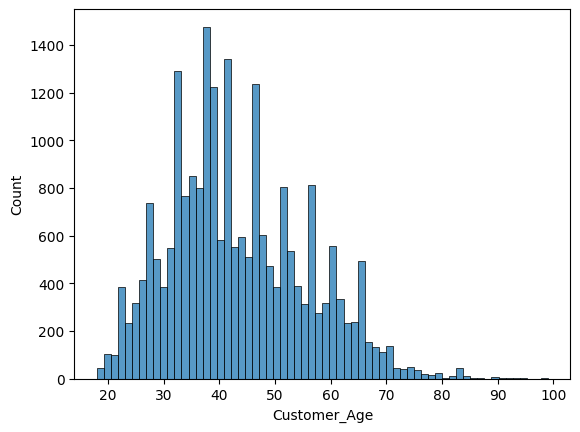

In [21]:
sns.histplot(df['Customer_Age'])

In [22]:
df['Customer_Age'].describe()

count    22629.000000
mean        43.282293
std         12.328220
min         18.000000
25%         34.000000
50%         41.000000
75%         52.000000
max         99.000000
Name: Customer_Age, dtype: float64

In [23]:
print("Mean Age:", df['Customer_Age'].mean())
print("Median Age:", df['Customer_Age'].median())

Mean Age: 43.28229263334659
Median Age: 41.0


<Axes: xlabel='Rating', ylabel='count'>

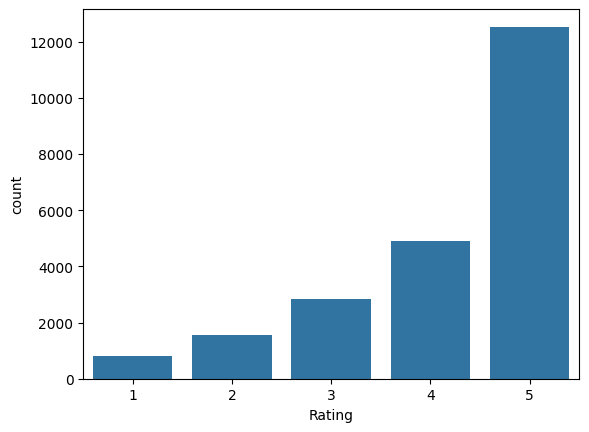

In [24]:
sns.countplot(x='Rating', data=df)

<Axes: xlabel='Recommend_Flag', ylabel='count'>

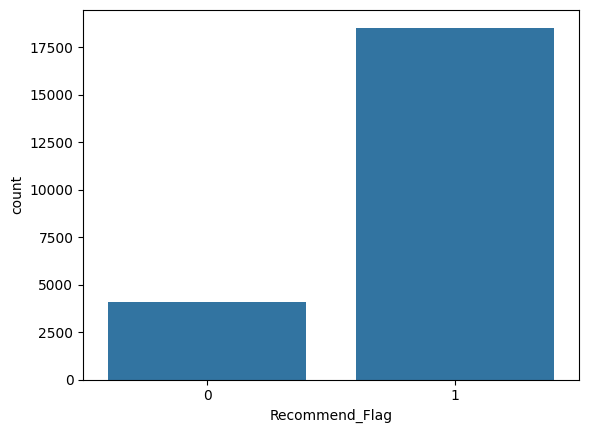

In [25]:
sns.countplot(x='Recommend_Flag', data=df)

<Axes: xlabel='Rating', ylabel='count'>

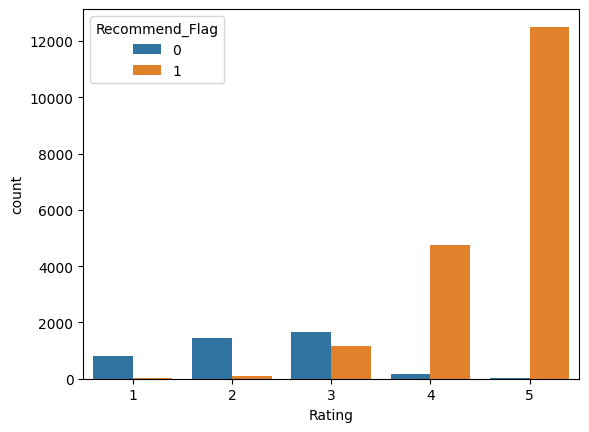

In [26]:
sns.countplot(
    x='Rating',
    hue='Recommend_Flag',
    data=df
)

In [27]:
# Category Analysis

In [28]:
category_rating = df.groupby('Category')['Rating'].mean().sort_values(ascending=False)

In [29]:
category_rating

Category
Initmates         4.275596
General Petite    4.196631
General           4.165345
Name: Rating, dtype: float64

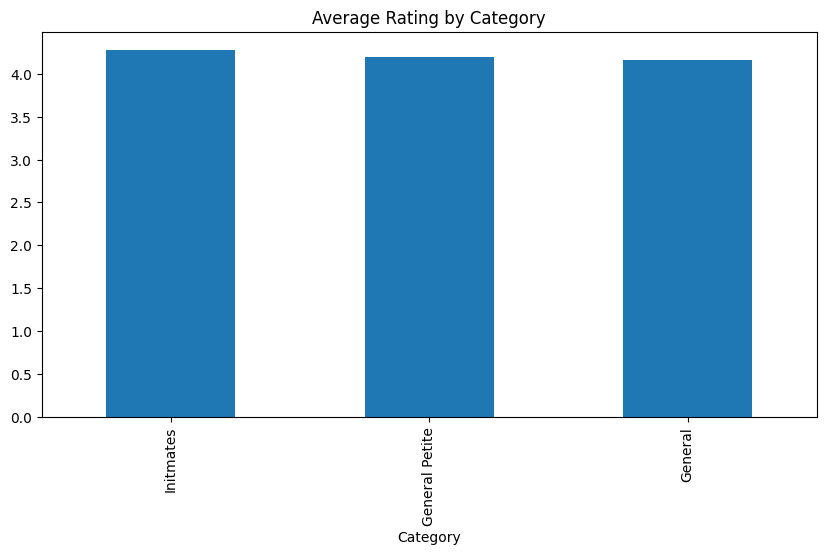

In [30]:
plt.figure(figsize=(10,5))

category_rating.plot(kind='bar')

plt.title('Average Rating by Category')
plt.show()

In [31]:
# Channel Analysis

In [32]:
df.groupby('Channel')[['Rating', 'Recommend_Flag']].mean()

,Rating,Recommend_Flag
Channel,,
Mobile,4.200231,0.821784
Web,4.170665,0.816578


In [33]:
# Location Analysis

In [34]:
location_rating = df.groupby('Location')['Rating'].mean().sort_values(ascending=False)

In [35]:
location_rating

Location
Mumbai       4.193261
Chennai      4.186690
Bangalore    4.178487
Gurgaon      4.176762
Name: Rating, dtype: float64

In [36]:
# Age Group Analysis

In [37]:
bins = [0,20,30,40,50,60,100]

labels = ['<20', '20-30', '30-40', '40-50', '50-60', '60+']

In [38]:
df['Age_Group'] = pd.cut(df['Customer_Age'], bins=bins, labels=labels)

In [39]:
df

,Product_ID,Category,Subcategory1,SubCategory2,Location,Channel,Customer_Age,Review_Title,Review_Text,Rating,Recommend_Flag,Review,Age_Group
0,767,Initmates,Intimate,Intimates,Mumbai,Mobile,33,,Absolutely wonderful - silky and sexy and comf...,4,1,Absolutely wonderful - silky and sexy and com...,30-40
1,1080,General,Dresses,Dresses,Bangalore,Mobile,34,,Love this dress! it's sooo pretty. i happene...,5,1,Love this dress! it's sooo pretty. i happen...,30-40
2,1077,General,Dresses,Dresses,Gurgaon,Mobile,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,Some major design flaws I had such high hopes ...,50-60
3,1049,General Petite,Bottoms,Pants,Chennai,Web,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,"My favorite buy! I love, love, love this jumps...",40-50
4,847,General,Tops,Blouses,Bangalore,Web,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,Flattering shirt This shirt is very flattering...,40-50
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23481,1104,General Petite,Dresses,Dresses,Gurgaon,Mobile,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,Great dress for many occasions I was very happ...,30-40
23482,862,General Petite,Tops,Knits,Gurgaon,Web,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,Wish it was made of cotton It reminds me of ma...,40-50
23483,1104,General Petite,Dresses,Dresses,Gurgaon,Web,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,"Cute, but see through This fit well, but the t...",30-40
23484,1084,General,Dresses,Dresses,Gurgaon,Web,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,"Very cute dress, perfect for summer parties an...",20-30


In [40]:
age_analysis = df.groupby('Age_Group')[['Rating', 'Recommend_Flag']].mean().round(2)

In [41]:
age_analysis

,Rating,Recommend_Flag
Age_Group,,
<20,4.31,0.87
20-30,4.17,0.81
30-40,4.15,0.81
40-50,4.15,0.81
50-60,4.24,0.84
60+,4.29,0.85


In [42]:
# Text Cleaning

In [43]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

In [44]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()

    words = [lemmatizer.lemmatize(word)
             for word in words
             if word not in stop_words]
    return ' '.join(words)

In [45]:
df['Clean_Review'] = (df['Review'].apply(clean_text))

In [46]:
df

,Product_ID,Category,Subcategory1,SubCategory2,Location,Channel,Customer_Age,Review_Title,Review_Text,Rating,Recommend_Flag,Review,Age_Group,Clean_Review
0,767,Initmates,Intimate,Intimates,Mumbai,Mobile,33,,Absolutely wonderful - silky and sexy and comf...,4,1,Absolutely wonderful - silky and sexy and com...,30-40,absolutely wonderful silky sexy comfortable
1,1080,General,Dresses,Dresses,Bangalore,Mobile,34,,Love this dress! it's sooo pretty. i happene...,5,1,Love this dress! it's sooo pretty. i happen...,30-40,love dress sooo pretty happened find store gla...
2,1077,General,Dresses,Dresses,Gurgaon,Mobile,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,Some major design flaws I had such high hopes ...,50-60,major design flaw high hope dress really wante...
3,1049,General Petite,Bottoms,Pants,Chennai,Web,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,"My favorite buy! I love, love, love this jumps...",40-50,favorite buy love love love jumpsuit fun flirt...
4,847,General,Tops,Blouses,Bangalore,Web,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,Flattering shirt This shirt is very flattering...,40-50,flattering shirt shirt flattering due adjustab...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23481,1104,General Petite,Dresses,Dresses,Gurgaon,Mobile,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,Great dress for many occasions I was very happ...,30-40,great dress many occasion happy snag dress gre...
23482,862,General Petite,Tops,Knits,Gurgaon,Web,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,Wish it was made of cotton It reminds me of ma...,40-50,wish made cotton reminds maternity clothes sof...
23483,1104,General Petite,Dresses,Dresses,Gurgaon,Web,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,"Cute, but see through This fit well, but the t...",30-40,cute see fit well top see never would worked g...
23484,1084,General,Dresses,Dresses,Gurgaon,Web,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,"Very cute dress, perfect for summer parties an...",20-30,cute dress perfect summer party bought dress w...


In [47]:
sia =  SentimentIntensityAnalyzer()

In [48]:
df['Sentiment_Score'] = (df['Review'].apply(lambda x: sia.polarity_scores(x)['compound']))

In [49]:
df

,Product_ID,Category,Subcategory1,SubCategory2,Location,Channel,Customer_Age,Review_Title,Review_Text,Rating,Recommend_Flag,Review,Age_Group,Clean_Review,Sentiment_Score
0,767,Initmates,Intimate,Intimates,Mumbai,Mobile,33,,Absolutely wonderful - silky and sexy and comf...,4,1,Absolutely wonderful - silky and sexy and com...,30-40,absolutely wonderful silky sexy comfortable,0.8932
1,1080,General,Dresses,Dresses,Bangalore,Mobile,34,,Love this dress! it's sooo pretty. i happene...,5,1,Love this dress! it's sooo pretty. i happen...,30-40,love dress sooo pretty happened find store gla...,0.9729
2,1077,General,Dresses,Dresses,Gurgaon,Mobile,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,Some major design flaws I had such high hopes ...,50-60,major design flaw high hope dress really wante...,0.9427
3,1049,General Petite,Bottoms,Pants,Chennai,Web,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,"My favorite buy! I love, love, love this jumps...",40-50,favorite buy love love love jumpsuit fun flirt...,0.7182
4,847,General,Tops,Blouses,Bangalore,Web,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,Flattering shirt This shirt is very flattering...,40-50,flattering shirt shirt flattering due adjustab...,0.9436
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23481,1104,General Petite,Dresses,Dresses,Gurgaon,Mobile,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,Great dress for many occasions I was very happ...,30-40,great dress many occasion happy snag dress gre...,0.9508
23482,862,General Petite,Tops,Knits,Gurgaon,Web,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,Wish it was made of cotton It reminds me of ma...,40-50,wish made cotton reminds maternity clothes sof...,0.7430
23483,1104,General Petite,Dresses,Dresses,Gurgaon,Web,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,"Cute, but see through This fit well, but the t...",30-40,cute see fit well top see never would worked g...,0.9625
23484,1084,General,Dresses,Dresses,Gurgaon,Web,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,"Very cute dress, perfect for summer parties an...",20-30,cute dress perfect summer party bought dress w...,0.9211


In [50]:
def sentiment(score):
    if score >= 0.05:
        return "Positive"
    
    elif score <= -0.05:
        return 'Negative'
    
    else:
        return 'Neutral'

In [51]:
df['Sentiment'] = (df['Sentiment_Score'].apply(sentiment))

In [52]:
df['Sentiment'].value_counts()

Sentiment
Positive    21152
Negative     1289
Neutral       188
Name: count, dtype: int64

In [53]:
df

,Product_ID,Category,Subcategory1,SubCategory2,Location,Channel,Customer_Age,Review_Title,Review_Text,Rating,Recommend_Flag,Review,Age_Group,Clean_Review,Sentiment_Score,Sentiment
0,767,Initmates,Intimate,Intimates,Mumbai,Mobile,33,,Absolutely wonderful - silky and sexy and comf...,4,1,Absolutely wonderful - silky and sexy and com...,30-40,absolutely wonderful silky sexy comfortable,0.8932,Positive
1,1080,General,Dresses,Dresses,Bangalore,Mobile,34,,Love this dress! it's sooo pretty. i happene...,5,1,Love this dress! it's sooo pretty. i happen...,30-40,love dress sooo pretty happened find store gla...,0.9729,Positive
2,1077,General,Dresses,Dresses,Gurgaon,Mobile,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,Some major design flaws I had such high hopes ...,50-60,major design flaw high hope dress really wante...,0.9427,Positive
3,1049,General Petite,Bottoms,Pants,Chennai,Web,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,"My favorite buy! I love, love, love this jumps...",40-50,favorite buy love love love jumpsuit fun flirt...,0.7182,Positive
4,847,General,Tops,Blouses,Bangalore,Web,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,Flattering shirt This shirt is very flattering...,40-50,flattering shirt shirt flattering due adjustab...,0.9436,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23481,1104,General Petite,Dresses,Dresses,Gurgaon,Mobile,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,Great dress for many occasions I was very happ...,30-40,great dress many occasion happy snag dress gre...,0.9508,Positive
23482,862,General Petite,Tops,Knits,Gurgaon,Web,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,Wish it was made of cotton It reminds me of ma...,40-50,wish made cotton reminds maternity clothes sof...,0.7430,Positive
23483,1104,General Petite,Dresses,Dresses,Gurgaon,Web,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,"Cute, but see through This fit well, but the t...",30-40,cute see fit well top see never would worked g...,0.9625,Positive
23484,1084,General,Dresses,Dresses,Gurgaon,Web,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,"Very cute dress, perfect for summer parties an...",20-30,cute dress perfect summer party bought dress w...,0.9211,Positive


<Axes: xlabel='Sentiment', ylabel='count'>

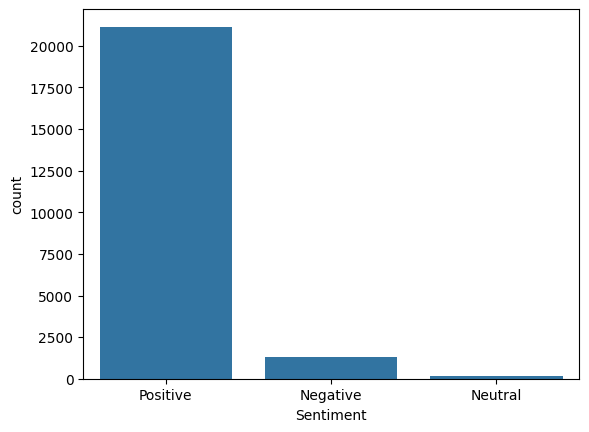

In [54]:
sns.countplot(x = 'Sentiment', data= df)

In [55]:
pd.crosstab(df['Category'], df['Sentiment'])

Sentiment,Negative,Neutral,Positive
Category,,,
General,783,112,12471
General Petite,426,59,7352
Initmates,80,17,1329


In [56]:
positive_reviews = df[df['Sentiment'] == 'Positive']

In [57]:
positive_reviews

,Product_ID,Category,Subcategory1,SubCategory2,Location,Channel,Customer_Age,Review_Title,Review_Text,Rating,Recommend_Flag,Review,Age_Group,Clean_Review,Sentiment_Score,Sentiment
0,767,Initmates,Intimate,Intimates,Mumbai,Mobile,33,,Absolutely wonderful - silky and sexy and comf...,4,1,Absolutely wonderful - silky and sexy and com...,30-40,absolutely wonderful silky sexy comfortable,0.8932,Positive
1,1080,General,Dresses,Dresses,Bangalore,Mobile,34,,Love this dress! it's sooo pretty. i happene...,5,1,Love this dress! it's sooo pretty. i happen...,30-40,love dress sooo pretty happened find store gla...,0.9729,Positive
2,1077,General,Dresses,Dresses,Gurgaon,Mobile,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,Some major design flaws I had such high hopes ...,50-60,major design flaw high hope dress really wante...,0.9427,Positive
3,1049,General Petite,Bottoms,Pants,Chennai,Web,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,"My favorite buy! I love, love, love this jumps...",40-50,favorite buy love love love jumpsuit fun flirt...,0.7182,Positive
4,847,General,Tops,Blouses,Bangalore,Web,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,Flattering shirt This shirt is very flattering...,40-50,flattering shirt shirt flattering due adjustab...,0.9436,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23481,1104,General Petite,Dresses,Dresses,Gurgaon,Mobile,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,Great dress for many occasions I was very happ...,30-40,great dress many occasion happy snag dress gre...,0.9508,Positive
23482,862,General Petite,Tops,Knits,Gurgaon,Web,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,Wish it was made of cotton It reminds me of ma...,40-50,wish made cotton reminds maternity clothes sof...,0.7430,Positive
23483,1104,General Petite,Dresses,Dresses,Gurgaon,Web,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,"Cute, but see through This fit well, but the t...",30-40,cute see fit well top see never would worked g...,0.9625,Positive
23484,1084,General,Dresses,Dresses,Gurgaon,Web,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,"Very cute dress, perfect for summer parties an...",20-30,cute dress perfect summer party bought dress w...,0.9211,Positive


In [58]:
from collections import Counter

In [59]:
positive_words = ' '.join(positive_reviews['Clean_Review'])

In [60]:
words_counts = Counter(positive_words.split())

In [61]:
words_counts.most_common(20)

[('dress', 12389),
 ('love', 10640),
 ('fit', 10450),
 ('top', 9190),
 ('size', 9187),
 ('great', 7778),
 ('color', 7103),
 ('like', 6928),
 ('look', 6659),
 ('wear', 6397),
 ('x', 5233),
 ('fabric', 4774),
 ('small', 4768),
 ('would', 4763),
 ('perfect', 4546),
 ('cute', 4417),
 ('beautiful', 4254),
 ('flattering', 3849),
 ('really', 3814),
 ('little', 3793)]

In [62]:
negative_reviews = df[df['Sentiment'] == 'Negative']

In [63]:
negative_words = ' '.join(negative_reviews['Clean_Review'])

In [64]:
Counter(negative_words.split()).most_common(20)

[('dress', 642),
 ('like', 445),
 ('size', 426),
 ('look', 402),
 ('fit', 373),
 ('fabric', 360),
 ('would', 334),
 ('top', 325),
 ('back', 316),
 ('color', 310),
 ('x', 286),
 ('small', 274),
 ('ordered', 252),
 ('wear', 232),
 ('really', 230),
 ('one', 228),
 ('shirt', 226),
 ('material', 220),
 ('quality', 218),
 ('disappointed', 217)]

In [65]:
wordcloud = WordCloud(width= 800, height= 400, background_color= 'white').generate(positive_words)

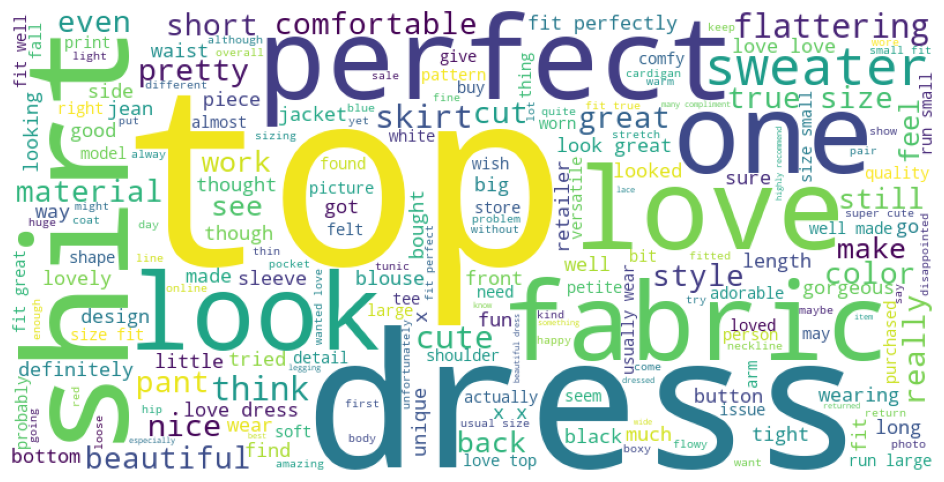

In [66]:
plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [67]:
wordcloud = WordCloud(width= 800, height= 400, background_color= 'white').generate(negative_words)

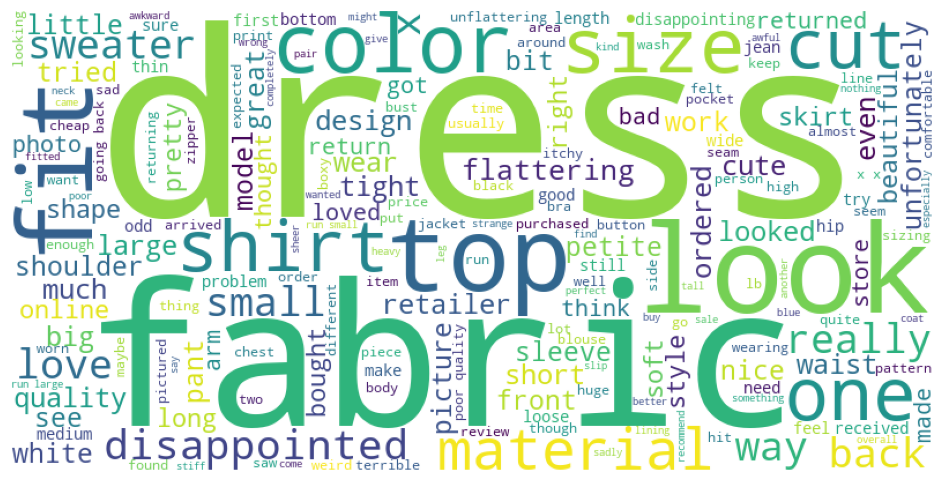

In [68]:
plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [69]:
# Topic Modeling(LDA)

In [70]:
vectorizer =  CountVectorizer(max_df=0.95, min_df=2, stop_words='english')

In [71]:
dtm = vectorizer.fit_transform(df['Clean_Review'])

In [72]:
lda = LatentDirichletAllocation(n_components=5, random_state=42)

In [73]:
lda.fit(dtm)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",5
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [74]:
for index, topic in enumerate(lda.components_):
    print(f"\nTopic {index+1}")
    print([vectorizer.get_feature_names_out()[i]
           for i in topic.argsort()[-10:]])


Topic 1
['bought', 'cute', 'small', 'color', 'store', 'wear', 'fit', 'love', 'size', 'dress']

Topic 2
['comfortable', 'jacket', 'wear', 'flattering', 'perfect', 'skirt', 'fit', 'love', 'great', 'dress']

Topic 3
['comfortable', 'like', 'pair', 'great', 'wear', 'love', 'jean', 'fit', 'size', 'pant']

Topic 4
['fit', 'wear', 'like', 'look', 'soft', 'shirt', 'great', 'sweater', 'love', 'color']

Topic 5
['ordered', 'really', 'large', 'fabric', 'small', 'look', 'fit', 'like', 'dress', 'size']


In [86]:
# Recommendation Prediction

In [75]:
y = df['Recommend_Flag']

In [78]:
tfidf = TfidfVectorizer(max_features = 5000)

In [79]:
X = tfidf.fit_transform(df['Clean_Review'])

In [80]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.2, random_state= 42)

In [81]:
model = LogisticRegression()

In [82]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [83]:
pred = model.predict(X_test)

In [84]:
accuracy_score(y_test, pred)

0.9010163499779055

In [85]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.83      0.57      0.68       819
           1       0.91      0.97      0.94      3707

    accuracy                           0.90      4526
   macro avg       0.87      0.77      0.81      4526
weighted avg       0.90      0.90      0.89      4526

